In [1]:
# Logistic Regression
# Linear Regression number predict karti thi. Logistic Regression classification ke liye use hoti hai.


In [2]:
# Linear Regression yahan kyun nahi?

# Agar hum Linear Regression use karein:

# Hours → 0 or 1

# toh theoretically line kuch aisi predictions de sakti hai:

# -0.2
# 0.3
# 0.7
# 1.2
# 1.5

# Problem ye hai ke classification mein hume probabilities chahiye jo:

# 0 se 1

# ke beech hon.

# Hum nahi chahte:

# Probability = 1.7
# Probability = -0.4

# Ye probability nahi ho sakti.

# Isliye Logistic Regression ek special function use karti hai jo kisi bhi real number ko 0 aur 1 ke beech convert kar deti hai.

# Us function ko Sigmoid function kehte hain.

In [3]:
# Lekin model sigmoid se pehle kya karta hai?

# Yahan Linear Regression wali understanding kaam aati hai.

# Model pehle ek linear combination banata hai:

# z = b0 + b1x1 + b2x2 + ...

# Phir:

# z
# ↓
# Sigmoid
# ↓
# Probability

# So complete flow:

# Input
#   ↓
# Linear calculation
#   ↓
# z
#   ↓
# Sigmoid
#   ↓
# Probability
#   ↓
# Class

# For example:

# Hours = 3

# model score z = -2.5

# sigmoid(-2.5)
#         ↓
# probability ≈ 0.08
#         ↓
# 8% chance of Pass

# Another student:

# Hours = 7

# z = 2.5

# sigmoid(2.5)
#       ↓
# probability ≈ 0.92
#       ↓
# 92% chance of Pass

# Ab model directly "Pass" nahi bol raha.

# Pehle:

# "Pass hone ki probability approximately 92% hai."

# Phir probability ko class mein convert kiya jata hai

In [4]:
# Logistic Regression actually kab use hoti hai?

# Jab target categorical, especially binary, ho.

# Examples:

# Spam / Not Spam
# Pass / Fail
# Fraud / Not Fraud
# Churn / No Churn
# Approved / Rejected
# Disease / No Disease

# Aur multiple-class versions bhi possible hain, jaise:

# Cat
# Dog
# Horse

# Lekin abhi binary classification par focus karo.

# Kab use nahi karni?

# Agar target naturally continuous numerical value hai:

# House Price
# Salary
# Temperature
# Sales
# Marks

# toh Linear Regression type regression methods zyada natural hain.

# Aur agar relationship/data structure Logistic Regression ke linear decision boundary assumption ke liye unsuitable ho, toh doosre algorithms better ho sakte hain.

# For example, agar classes ka pattern bohat complicated/nonlinear ho:

#      ● ● ●
#    ●       ●
#   ●   ○ ○   ●
#    ●       ●
#      ● ● ●

# toh simple Logistic Regression struggle kar sakti hai because its basic decision boundary is linear.

In [5]:
# acutal data set
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [6]:
# dataset
data = {
    "Exam_Score": [
        45, 50, 52, 55, 58,
        60, 62, 64, 66, 68,
        70, 72, 74, 76, 78,
        80, 82, 85, 88, 92
    ],

    "Interview_Score": [
        42, 48, 45, 50, 52,
        55, 50, 58, 60, 62,
        65, 60, 68, 70, 72,
        75, 78, 80, 85, 90
    ],

    "Admitted": [
        0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

df.head()

,Exam_Score,Interview_Score,Admitted
0,45,42,0
1,50,48,0
2,52,45,0
3,55,50,0
4,58,52,0


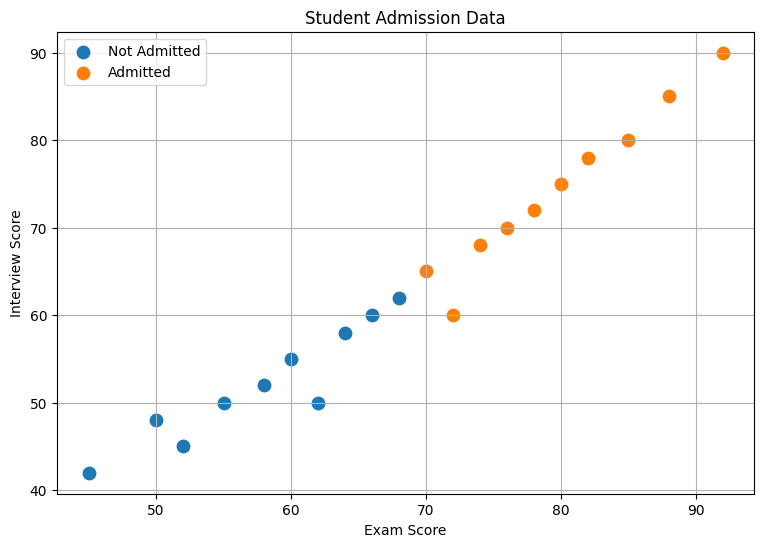

In [7]:
# lets visualize the data
plt.figure(figsize=(9, 6))

plt.scatter(
    df[df["Admitted"] == 0]["Exam_Score"],
    df[df["Admitted"] == 0]["Interview_Score"],
    s=80,
    label="Not Admitted"
)

plt.scatter(
    df[df["Admitted"] == 1]["Exam_Score"],
    df[df["Admitted"] == 1]["Interview_Score"],
    s=80,
    label="Admitted"
)

plt.xlabel("Exam Score")
plt.ylabel("Interview Score")
plt.title("Student Admission Data")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# x and y
X = df[
    [
        "Exam_Score",
        "Interview_Score"
    ]
]

y = df["Admitted"]

In [9]:
# X → input features
# y → class

In [11]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# stratify=y yahan isliye use kiya hai taake train/test mein classes ka
# distribution reasonable rahe

In [14]:
# model
model = LogisticRegression()
model.fit(
    X_train,
    y_train
)
# Training data se model ke parameters learn karo.

LogisticRegression()

In [15]:
# predictions
new_student = pd.DataFrame({
    "Exam_Score": [75],
    "Interview_Score": [70]
})

prediction = model.predict(new_student)

print("Predicted Class:", prediction[0])

Predicted Class: 1


In [16]:
# output one aya ha matlab k admited ha

In [17]:
# probabilities - jo k z ki value ko sigmoid me dal k ati ha hamare pass
probability = model.predict_proba(new_student)

print(probability)

[[4.63679233e-04 9.99536321e-01]]


In [18]:
# 0.046 % class 0
# 99.95 percent ha class 1

In [20]:
# predict_proba()

# Probability deta hai.

# predict()

# Final class deta hai.

In [21]:
# multiple students ki prediction
predicted_classes = model.predict(X_test)

predicted_probabilities = model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["Actual"] = y_test.values
results["Probability_Admitted"] = predicted_probabilities
results["Predicted"] = predicted_classes

results.sort_index()

,Exam_Score,Interview_Score,Actual,Probability_Admitted,Predicted
3,55,50,0,7.246076e-08,0
6,62,50,0,4.000805e-05,0
12,74,68,1,9.979052e-01,1
16,82,78,1,9.999999e-01,1


In [22]:
# decision boundary graph
x_min = df["Exam_Score"].min() - 5
x_max = df["Exam_Score"].max() + 5

y_min = df["Interview_Score"].min() - 5
y_max = df["Interview_Score"].max() + 5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = pd.DataFrame({
    "Exam_Score": xx.ravel(),
    "Interview_Score": yy.ravel()
})

probabilities = model.predict_proba(grid)[:, 1]

Z = probabilities.reshape(xx.shape)

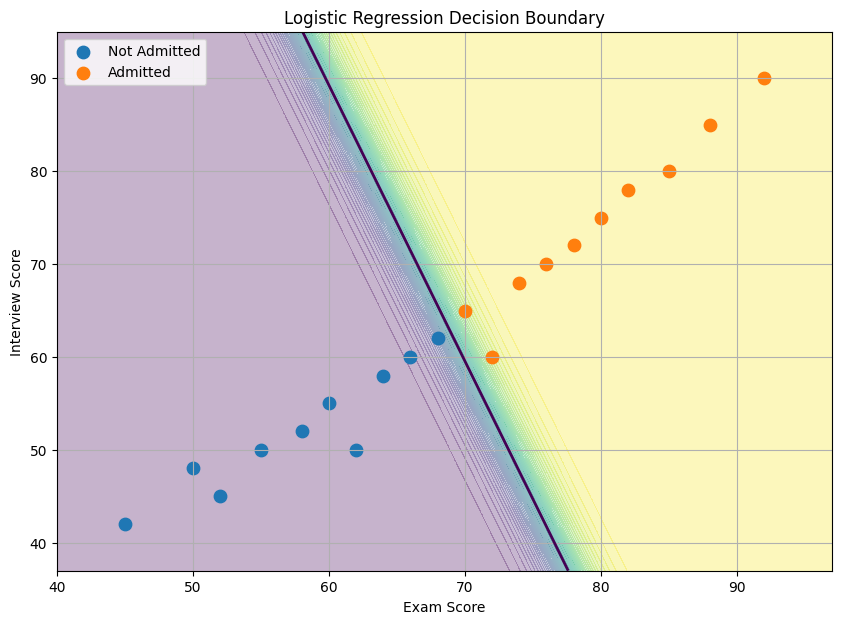

In [23]:
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    levels=50,
    alpha=0.3
)

plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5],
    linewidths=2
)

plt.scatter(
    df[df["Admitted"] == 0]["Exam_Score"],
    df[df["Admitted"] == 0]["Interview_Score"],
    s=80,
    label="Not Admitted"
)

plt.scatter(
    df[df["Admitted"] == 1]["Exam_Score"],
    df[df["Admitted"] == 1]["Interview_Score"],
    s=80,
    label="Admitted"
)

plt.xlabel("Exam Score")
plt.ylabel("Interview Score")
plt.title("Logistic Regression Decision Boundary")

plt.legend()
plt.grid(True)

plt.show()

In [24]:
# evaluation
# accuracy
accuracy = accuracy_score(
    y_test,
    predicted_classes
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [25]:
# confusion matrix
cm = confusion_matrix(
    y_test,
    predicted_classes
)

print(cm)

[[2 0]
 [0 2]]


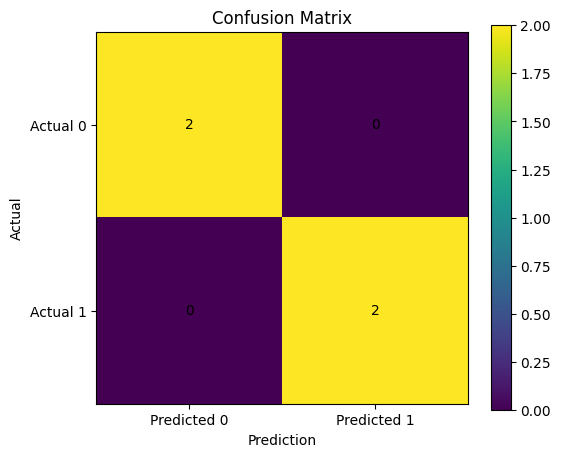

In [26]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["Predicted 0", "Predicted 1"]
)

plt.yticks(
    [0, 1],
    ["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [28]:
# # linear vs logistic regression
# aam mein "Regression" hai, but practical use yahan classification hai.

# Linear Regression
# Input
#  ↓
# straight-line relationship
#  ↓
# continuous number

# Example:

# Hours → Marks

# Prediction:

# 73.5
# Logistic Regression
# Input
#  ↓
# linear score
#  ↓
# sigmoid
#  ↓
# probability
#  ↓
# class

# Example:

# Exam + Interview
#        ↓
# Probability of Admission
#        ↓
# 0.87
#        ↓
# Class = 1

In [29]:
# Logistic Regression ek supervised classification algorithm hai jo
# input features se class ki probability estimate karta hai. Ye linear
# combination ko sigmoid function se probability mein convert karta hai,
# phir threshold use karke final class predict karta hai.